**Taller 7 - Problemas desbalanceados**

Diego Andrés Burbano A.


## 1. Importar librerias necesarias para el modelo

In [1]:
#Importar librerias necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import time
from random import random, seed
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from scipy.stats import uniform, randint
from random import random, seed
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, KFold, cross_validate, cross_val_predict, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score , average_precision_score, f1_score, classification_report, precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import xgboost as xgb
from xgboost.sklearn import XGBClassifier
from xgboost import plot_importance

import os
from google.colab import drive

## 2. Carga de datos

In [2]:
# En esta celda se esta montando el drive  que tiene almacenado los datos en la ruta MyDrive/datos
drive.mount('/content/drive', force_remount=True)

# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/datos/')

Mounted at /content/drive


Revisión preliminar de datos

In [3]:
df = pd.read_csv('train_taller7.csv').drop(['id','Product ID'], axis=1)
df.columns = ['Type', 'Air temperature', 'Process temperature',
       'Rotational speed ', 'Torque ', 'Tool wear ',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

In [4]:
#Cantidad y dimensionalidad de los datos
df.shape

(136429, 12)

In [5]:
X = df.drop('Machine failure',axis=1)
X = pd.get_dummies(X)
y = df['Machine failure']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=145)

Machine failure
0    134281
1      2148
Name: count, dtype: int64
Machine failure
0    0.984256
1    0.015744
Name: count, dtype: float64


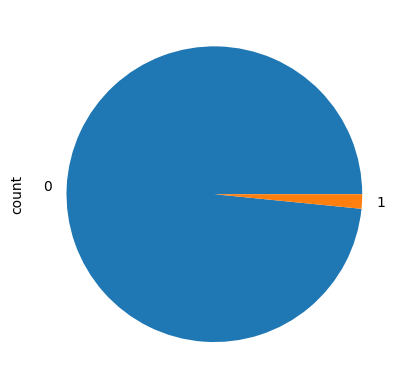

In [7]:
y.value_counts().plot(kind='pie')
print(y.value_counts())
print(y.value_counts()/y.shape )

In [13]:
def see_results(resultados, top_n=10):
    params_df = pd.json_normalize(resultados["params"])
    df = pd.concat(
        [resultados[["mean_test_score", "std_test_score", "rank_test_score"]], params_df],
        axis=1
    )
    df = df.sort_values("rank_test_score").reset_index(drop=True)
    display(df.head(top_n))
    return df


In [22]:
def report_best_scores(resultados):
    best_idx = resultados["rank_test_score"].idxmin()
    best_row = resultados.loc[best_idx]

    print("Mejor resultado encontrado:")
    print(f"- Score medio (F1 weighted): {best_row['mean_test_score']:.4f}")
    print(f"- Desviación estándar: {best_row['std_test_score']:.4f}")
    print(f"- Parámetros: {best_row['params']}")

    return best_row["params"]


##3. Entrenamiento base

#### 3.1 XGBoost: Búsqueda Aleatoria

In [10]:
# Definición de modelo base
xgb1 = XGBClassifier(n_jobs=-1, use_label_encoder=False, eval_metric="logloss")

# Espacio de hiperparámetros para la búsqueda
param_dist1 = {
    "n_estimators": np.arange(50, 300, 50),
    "max_depth": np.arange(3, 10, 1),
    "learning_rate": np.linspace(0.01, 0.3, 10),
    "subsample": np.linspace(0.7, 1.0, 4),
    "colsample_bytree": np.linspace(0.7, 1.0, 4)
}

# Randomized Search
search1 = RandomizedSearchCV(
    estimator=xgb1,
    param_distributions=param_dist1,
    n_iter=20,
    scoring="f1_weighted",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [11]:
# Entrenar
search1.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [03:56:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': array([0.7, 0.8, 0.9, 1. ]),
                                        'learning_rate': array([0.01      , 0.04222222, 0.07444444, 0.10666667, 0.13888889,
       0.17111111, 0.20333333, 0.23555556, 0.26777778, 0.3       ]),
                                        'max_depth': array([3, 4, 5, 6, 7, 8, 9]),
                                        'n_estimators': array([ 50, 100, 150, 200, 250]),
                                        'subsample': array([0.7, 0.8, 0.9, 1. ])},
                   random_state=42, scoring='f1_weighted', verbose=1)

In [23]:
# Resultados de la búsqueda aleatoria
resultados1 = pd.DataFrame(search1.cv_results_)

# Ver tabla ordenada
see_results(resultados1)

# Reportar el mejor modelo
best_model_under = report_best_scores(resultados1)
best_model_under


,mean_test_score,std_test_score,rank_test_score,subsample,n_estimators,max_depth,learning_rate,colsample_bytree
0,0.996012,0.000169,1,1.0,150,3,0.235556,1.0
1,0.995996,0.000247,2,0.8,100,3,0.074444,0.8
2,0.995986,0.000241,3,0.9,100,7,0.042222,1.0
3,0.995980,0.000231,4,0.7,100,7,0.138889,0.9
4,0.995978,0.000234,5,0.9,100,5,0.106667,0.7
5,0.995978,0.000234,5,0.7,200,3,0.074444,0.9
6,0.995973,0.000227,7,1.0,150,7,0.074444,0.9
7,0.995973,0.000208,8,1.0,150,3,0.203333,1.0
8,0.995971,0.000244,9,1.0,150,3,0.235556,0.8
9,0.995969,0.000226,10,0.7,50,4,0.203333,0.7


Mejor resultado encontrado:
- Score medio (F1 weighted): 0.9960
- Desviación estándar: 0.0002
- Parámetros: {'subsample': np.float64(1.0), 'n_estimators': np.int64(150), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.23555555555555557), 'colsample_bytree': np.float64(1.0)}


{'subsample': np.float64(1.0),
 'n_estimators': np.int64(150),
 'max_depth': np.int64(3),
 'learning_rate': np.float64(0.23555555555555557),
 'colsample_bytree': np.float64(1.0)}

In [24]:
# Evaluar en train
y_pred_train = search1.best_estimator_.predict(X_train)
print("EVALUACION EN TRAIN:")
print("\nReporte en Train:")
print(classification_report(y_train, y_pred_train))

# Evaluar en test
y_pred = search1.best_estimator_.predict(X_test)
print("EVALUACION EN TEST:")
print("\nReporte en Test:")
print(classification_report(y_test, y_pred))

EVALUACION EN TRAIN:

Reporte en Train:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    107408
           1       0.99      0.78      0.87      1735

    accuracy                           1.00    109143
   macro avg       0.99      0.89      0.94    109143
weighted avg       1.00      1.00      1.00    109143

EVALUACION EN TEST:

Reporte en Test:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26873
           1       0.98      0.75      0.85       413

    accuracy                           1.00     27286
   macro avg       0.99      0.87      0.92     27286
weighted avg       1.00      1.00      1.00     27286



#### 3.2 XGBoost: Búsqueda Aleatoria - Con submuestreo

Machine failure
0    1735
1    1735
Name: count, dtype: int64


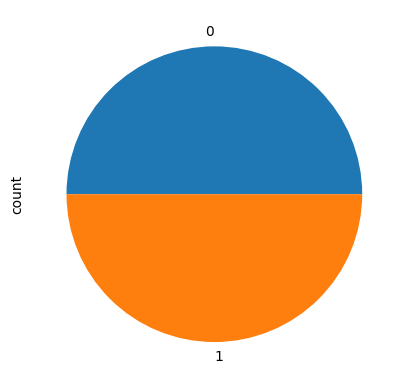

In [18]:
#Balanceo de datos empleando undersampling
under = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under.fit_resample(X_train, y_train)

#Visuzalización de la proporción de clases en los datos de entrenamiento
y_train_under.value_counts().plot(kind='pie')
print(y_train_under.value_counts())

In [19]:
# Definición de modelo base
xgb2 = XGBClassifier(n_jobs=-1, use_label_encoder=False, eval_metric="logloss")

# Espacio de hiperparámetros para la búsqueda
param_dist2 = {
    "n_estimators": np.arange(50, 300, 50),
    "max_depth": np.arange(3, 10, 1),
    "learning_rate": np.linspace(0.01, 0.3, 10),
    "subsample": np.linspace(0.7, 1.0, 4),
    "colsample_bytree": np.linspace(0.7, 1.0, 4)
}

# Randomized Search
search2 = RandomizedSearchCV(
    estimator=xgb2,
    param_distributions=param_dist2,
    n_iter=20,
    scoring="f1_weighted",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [20]:
# Entrenar
search2.fit(X_train_under, y_train_under)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [04:02:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': array([0.7, 0.8, 0.9, 1. ]),
                                        'learning_rate': array([0.01      , 0.04222222, 0.07444444, 0.10666667, 0.13888889,
       0.17111111, 0.20333333, 0.23555556, 0.26777778, 0.3       ]),
                                        'max_depth': array([3, 4, 5, 6, 7, 8, 9]),
                                        'n_estimators': array([ 50, 100, 150, 200, 250]),
                                        'subsample': array([0.7, 0.8, 0.9, 1. ])},
                   random_state=42, scoring='f1_weighted', verbose=1)

In [25]:
# Resultados de la búsqueda aleatoria
resultados2 = pd.DataFrame(search2.cv_results_)

# Ver tabla ordenada
see_results(resultados2)

# Reportar el mejor modelo
best_model_under2 = report_best_scores(resultados2)
best_model_under2

,mean_test_score,std_test_score,rank_test_score,subsample,n_estimators,max_depth,learning_rate,colsample_bytree
0,0.916291,0.006585,1,0.9,100,7,0.042222,1.0
1,0.914588,0.004623,2,0.7,200,3,0.074444,0.9
2,0.914588,0.004211,3,0.9,150,9,0.010000,0.7
3,0.914032,0.009658,4,1.0,150,7,0.074444,0.9
4,0.913707,0.006748,5,1.0,250,8,0.010000,0.9
5,0.912616,0.006198,6,0.7,100,7,0.138889,0.9
6,0.912561,0.002208,7,0.9,100,5,0.106667,0.7
7,0.911682,0.005434,8,0.7,50,4,0.203333,0.7
8,0.910570,0.004204,9,1.0,150,3,0.235556,1.0
9,0.910567,0.005379,10,1.0,150,3,0.203333,1.0


Mejor resultado encontrado:
- Score medio (F1 weighted): 0.9163
- Desviación estándar: 0.0066
- Parámetros: {'subsample': np.float64(0.9), 'n_estimators': np.int64(100), 'max_depth': np.int64(7), 'learning_rate': np.float64(0.042222222222222223), 'colsample_bytree': np.float64(1.0)}


{'subsample': np.float64(0.9),
 'n_estimators': np.int64(100),
 'max_depth': np.int64(7),
 'learning_rate': np.float64(0.042222222222222223),
 'colsample_bytree': np.float64(1.0)}

In [26]:
# Evaluar en train
y_pred_train = search2.best_estimator_.predict(X_train_under)
print("EVALUACION EN TRAIN - CON SUBMUESTREO:")
print("\nReporte en Train:")
print(classification_report(y_train_under, y_pred_train))

# Evaluar en test
y_pred = search2.best_estimator_.predict(X_test)
print("EVALUACION EN TEST - CON SUBMUESTREO:")
print("\nReporte en Test:")
print(classification_report(y_test, y_pred))

EVALUACION EN TRAIN - CON SUBMUESTREO:

Reporte en Train:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1735
           1       0.98      0.89      0.94      1735

    accuracy                           0.94      3470
   macro avg       0.94      0.94      0.94      3470
weighted avg       0.94      0.94      0.94      3470

EVALUACION EN TEST - CON SUBMUESTREO:

Reporte en Test:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     26873
           1       0.24      0.87      0.38       413

    accuracy                           0.96     27286
   macro avg       0.62      0.92      0.68     27286
weighted avg       0.99      0.96      0.97     27286



## 4. Implementación de pesos

#### 4.1 XGBoost: Búsqueda Aleatoria - Implementacion de pesos

In [27]:
# Calcular pesos
c1 = y_train.value_counts()[0]
c2 = y_train.value_counts()[1]
scale_pos_weight = c1/c2
print(scale_pos_weight)

61.90662824207493


In [28]:
# Modelo base con peso
xgb_w = XGBClassifier(
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

# Espacio de hiperparámetros
param_dist_w = {
    "n_estimators": np.arange(50, 300, 50),
    "max_depth": np.arange(3, 10, 1),
    "learning_rate": np.linspace(0.01, 0.3, 10),
    "subsample": np.linspace(0.7, 1.0, 4),
    "colsample_bytree": np.linspace(0.7, 1.0, 4)
}

# Randomized Search
search3 = RandomizedSearchCV(
    estimator=xgb_w,
    param_distributions=param_dist_w,
    n_iter=20,
    scoring="f1_weighted",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)


In [29]:
# Entrenar
search3.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [04:07:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': array([0.7, 0.8, 0.9, 1. ]),
                                        'learning_rate': array([0.01      , 0.04222222, 0.07444444, 0.10666667, 0.13888889,
       0.17111111, 0.20333333, 0.23555556, 0.26777778, 0.3       ]),
                                        'max_depth': array([3, 4, 5, 6, 7, 8, 9]),
                                        'n_estimators': array([ 50, 100, 150, 200, 250]),
                                        'subsample': array([0.7, 0.8, 0.9, 1. ])},
                   random_state=42, scoring='f1_weighted', verbose=1)

In [30]:
# Resultados de la búsqueda aleatoria
resultados3 = pd.DataFrame(search3.cv_results_)

# Ver tabla ordenada
see_results(resultados3)

# Reportar el mejor modelo
best_model_under3 = report_best_scores(resultados3)
best_model_under3

,mean_test_score,std_test_score,rank_test_score,subsample,n_estimators,max_depth,learning_rate,colsample_bytree
0,0.995110,0.000309,1,0.9,250,8,0.300000,1.0
1,0.994933,0.000235,2,0.7,200,9,0.203333,0.9
2,0.994788,0.000107,3,1.0,150,9,0.235556,1.0
3,0.993029,0.000462,4,0.9,150,6,0.267778,1.0
4,0.991549,0.000006,5,0.8,200,5,0.235556,0.8
5,0.990513,0.000163,6,0.8,150,6,0.171111,0.7
6,0.990102,0.000301,7,0.7,100,7,0.138889,0.9
7,0.986521,0.000353,8,0.9,100,5,0.235556,1.0
8,0.985691,0.000994,9,1.0,150,7,0.074444,0.9
9,0.983540,0.001346,10,0.9,150,9,0.010000,0.7


Mejor resultado encontrado:
- Score medio (F1 weighted): 0.9951
- Desviación estándar: 0.0003
- Parámetros: {'subsample': np.float64(0.9), 'n_estimators': np.int64(250), 'max_depth': np.int64(8), 'learning_rate': np.float64(0.3), 'colsample_bytree': np.float64(1.0)}


{'subsample': np.float64(0.9),
 'n_estimators': np.int64(250),
 'max_depth': np.int64(8),
 'learning_rate': np.float64(0.3),
 'colsample_bytree': np.float64(1.0)}

In [31]:
# Evaluar en train
y_pred_train_w = search3.best_estimator_.predict(X_train)
print("EVALUACION EN TRAIN CON IMPLEMENTACION DE PESOS:")
print("\nReporte en Train:")
print(classification_report(y_train, y_pred_train_w))

# Evaluar en test
y_pred_w = search3.best_estimator_.predict(X_test)
print("EVALUACION EN TEST CON IMPLEMENTACION DE PESOS:")
print("\nReporte en Test:")
print(classification_report(y_test, y_pred_w))

EVALUACION EN TRAIN CON IMPLEMENTACION DE PESOS:

Reporte en Train:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    107408
           1       0.98      1.00      0.99      1735

    accuracy                           1.00    109143
   macro avg       0.99      1.00      1.00    109143
weighted avg       1.00      1.00      1.00    109143

EVALUACION EN TEST CON IMPLEMENTACION DE PESOS:

Reporte en Test:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26873
           1       0.87      0.76      0.81       413

    accuracy                           0.99     27286
   macro avg       0.94      0.88      0.90     27286
weighted avg       0.99      0.99      0.99     27286



## Conclusiones



*   Los resultados del primero modelo con set desbalanceado y sin parámetro de ajuste scale_pos_weighted, es un modelo con altisimo accuracy, propio de un modelo desbalanceado hacia una de sus clases, y con una capacidad de predicción de días sin accidentes (clase 1) relativamente baja 0.75 en test. Es un modelo que pierde capacidad de predicción del número de los positivos (accidentes).   
*   Aplicando undersampling sobre el modelo 1, obtenemos el modelo 2. Se trata de un modelo en el cual se mejora su capacidad de predicción de los positivos ya que su recall aumento a 0.87. El costo de esta mejora esta en su baja capacidad de precisión de esta clase. Por ende en el momento de utlizarlo se van a dejar de escapar los eventos "accidentes" a costa de un aumento de falsas alarmas. En la práctica este hecho va a implicar que los usuarios no confien en el sistema, ya que va a dar muchas alarmas que no son ciertas.
*   En referencia al modelo 3, correspondiente a un modelo desbalanceado con parametro scale_pos_weighted, vemos que en la práctica es casi el mismo modelo 1. Si bien existe una leve mejora en el resultado del recall con referencia al modelo base (0.76 vs 0.75 para el conjunto test). Esta mejora no es considerable en términos prácticos. Adicionalmente en este modelo la leve mejora mencionada es a costa de una caida importante en la capacidad de precisión de esta clase ya que baja de 0.98 al 0.87. El bajo impacto del uso del parámetro scale_pos_weighted se puede deber a que éste se recomienda para set de datos que puedan llegar a presentar una diferencia mucho mas pronunciada en la clase positiva versus la clase negativa.
*   Algo importante a considerar para el modelo 3 es que presenta indicios de overfitting, ya que en train el recall es de 1.00 para ambas clases y se mantiene para la clase dominante y cae a 0.76 para la clase 1. Por lo tanto el modelo esta memorizando el patrón de la clase minoritaria en train pero cuando se enfrenta a nuevos casos no logra generalizar igual de bien.
*   De acuerdo con todo lo anterior, si lo que buscamos con este modelo es tener una mayor capacidad de predicción de las alarmas, el modelo 2 con undersampling sería el mas recomendado. Antes de ponerlo en producción este modelo se debe ajustar, por ejemplo calibrando el umbral de decisión. La gran ventaja del uso de un modelo como el XGBoost es que éste cuenta con muchos parámetros con los cuales se puede ajustar el modelo, tales como min_child_weight, gamma, reg_alpha, entre otros, ademas del ajuste de la regularización.
*   Alternativas adicionales de ajuste pueden incluir técnicas de oversampling (como SMOTE) para verificar si obtenemos un mejor balance entre precisión y recall sin sacrificar tanta información como en el undersampling.
